In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# connect to SQL Server
engine = create_engine(
    'mssql+pyodbc://LAPTOP-RNCU5CQF\SQLEXPRESS/EcommerceDB'
    '?driver=ODBC+Driver+17+for+SQL+Server'
    '&trusted_connection=yes'
)

# load data from SQL Server
df = pd.read_sql('SELECT * FROM online_retail', engine)

print(df.shape)
print(df.columns.tolist())
print(df.head())

(805549, 8)
['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']
  invoice_no stock_code                          description  quantity  \
0     489434      85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1     489434     79323P                   PINK CHERRY LIGHTS        12   
2     489434     79323W                  WHITE CHERRY LIGHTS        12   
3     489434      22041         RECORD FRAME 7" SINGLE SIZE         48   
4     489434      21232       STRAWBERRY CERAMIC TRINKET BOX        24   

         invoice_date  unit_price customer_id         country  
0 2009-12-01 07:45:00        6.95     13085.0  United Kingdom  
1 2009-12-01 07:45:00        6.75     13085.0  United Kingdom  
2 2009-12-01 07:45:00        6.75     13085.0  United Kingdom  
3 2009-12-01 07:45:00        2.10     13085.0  United Kingdom  
4 2009-12-01 07:45:00        1.25     13085.0  United Kingdom  


In [3]:
print(f"Total rows: {len(df)}")
print(f"Date range: {df['invoice_date'].min()} to {df['invoice_date'].max()}")
print(f"Unique customers: {df['customer_id'].nunique()}")
print(f"Unique products: {df['stock_code'].nunique()}")
print(f"Unique countries: {df['country'].nunique()}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)

Total rows: 805549
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5878
Unique products: 4631
Unique countries: 41

Missing values:
invoice_no      0
stock_code      0
description     0
quantity        0
invoice_date    0
unit_price      0
customer_id     0
country         0
dtype: int64

Data types:
invoice_no              object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
unit_price             float64
customer_id             object
country                 object
dtype: object


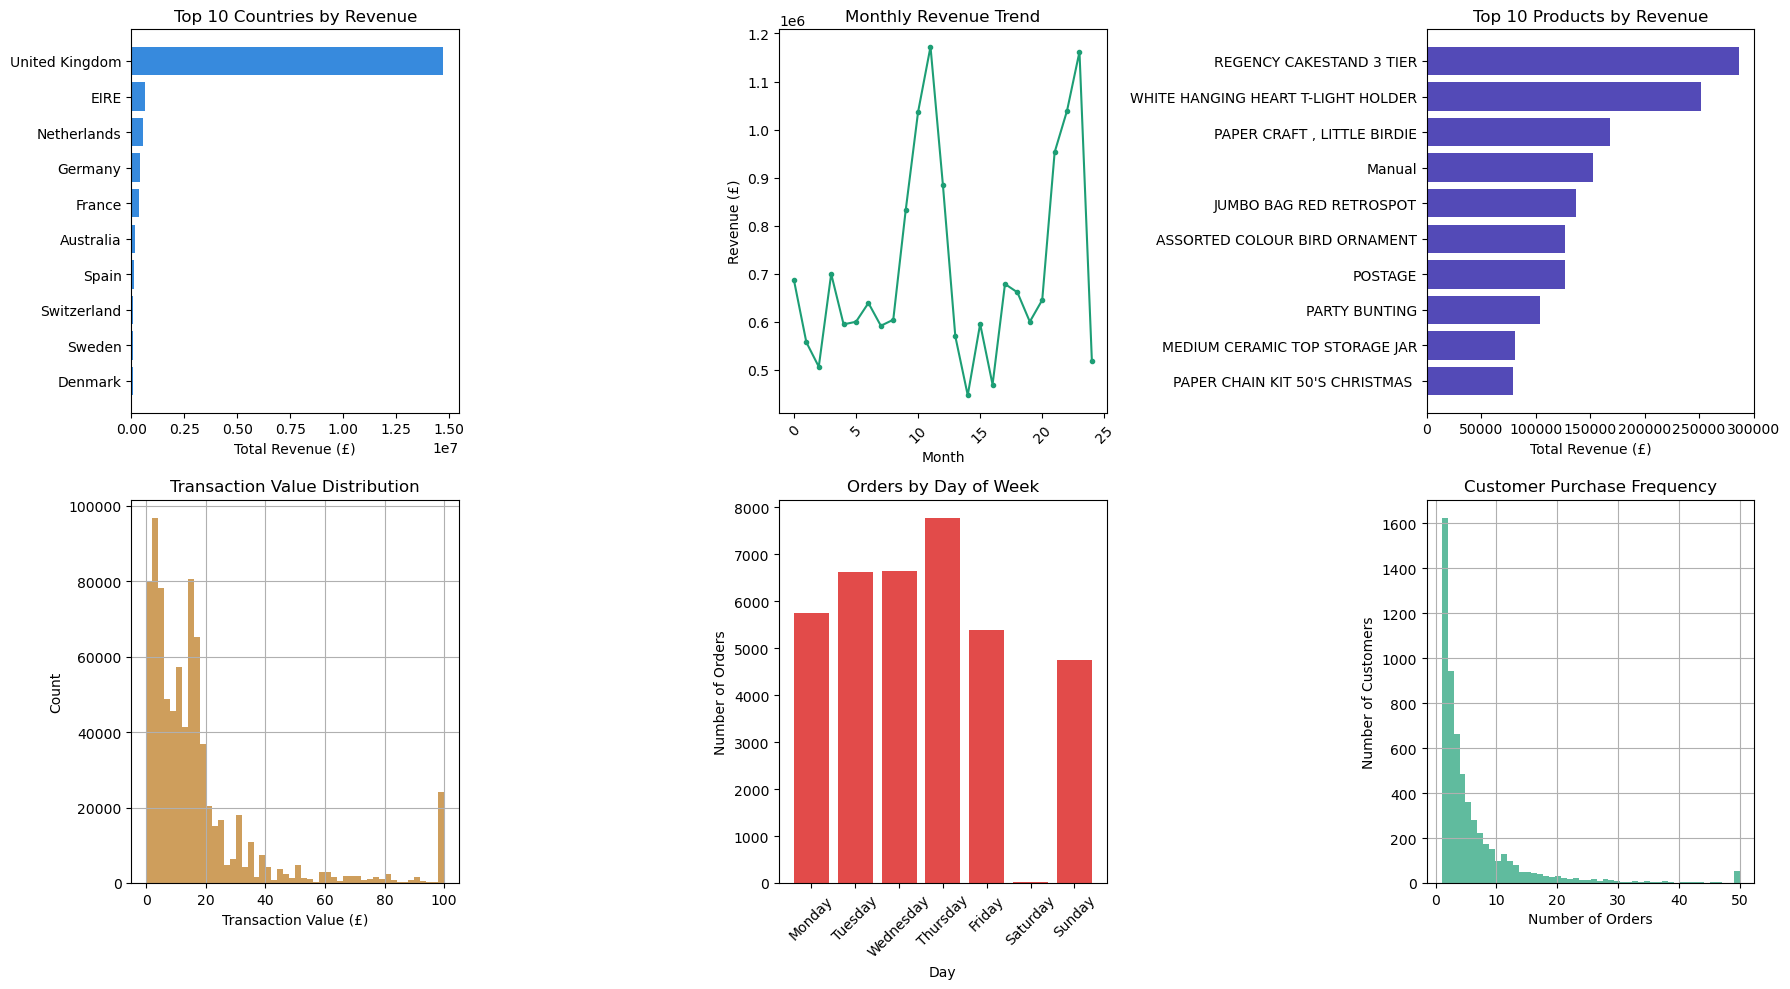

EDA plots saved.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1 — Top 10 countries by revenue
country_revenue = df.groupby('country').apply(
    lambda x: (x['quantity'] * x['unit_price']).sum()
).sort_values(ascending=False).head(10)

axes[0,0].barh(country_revenue.index[::-1], country_revenue.values[::-1], color='#378ADD')
axes[0,0].set_title('Top 10 Countries by Revenue')
axes[0,0].set_xlabel('Total Revenue (£)')

# Plot 2 — Monthly revenue trend
df['year_month'] = df['invoice_date'].dt.to_period('M')
monthly = df.groupby('year_month').apply(
    lambda x: (x['quantity'] * x['unit_price']).sum()
)
axes[0,1].plot(range(len(monthly)), monthly.values, color='#1D9E75', marker='o', ms=3)
axes[0,1].set_title('Monthly Revenue Trend')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Revenue (£)')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 — Top 10 products by revenue
product_revenue = df.groupby('description').apply(
    lambda x: (x['quantity'] * x['unit_price']).sum()
).sort_values(ascending=False).head(10)

axes[0,2].barh(product_revenue.index[::-1], product_revenue.values[::-1], color='#534AB7')
axes[0,2].set_title('Top 10 Products by Revenue')
axes[0,2].set_xlabel('Total Revenue (£)')

# Plot 4 — Revenue distribution per transaction
df['total_price'] = df['quantity'] * df['unit_price']
df['total_price'].clip(upper=100).hist(ax=axes[1,0], bins=50, color='#BA7517', alpha=0.7)
axes[1,0].set_title('Transaction Value Distribution')
axes[1,0].set_xlabel('Transaction Value (£)')
axes[1,0].set_ylabel('Count')

# Plot 5 — Orders by day of week
df['day_of_week'] = df['invoice_date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df.groupby('day_of_week')['invoice_no'].nunique().reindex(day_order)
axes[1,1].bar(day_counts.index, day_counts.values, color='#E24B4A')
axes[1,1].set_title('Orders by Day of Week')
axes[1,1].set_xlabel('Day')
axes[1,1].set_ylabel('Number of Orders')
axes[1,1].tick_params(axis='x', rotation=45)

# Plot 6 — Customer purchase frequency distribution
customer_freq = df.groupby('customer_id')['invoice_no'].nunique()
customer_freq.clip(upper=50).hist(ax=axes[1,2], bins=50, color='#1D9E75', alpha=0.7)
axes[1,2].set_title('Customer Purchase Frequency')
axes[1,2].set_xlabel('Number of Orders')
axes[1,2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig(r'C:\Users\sahil\ecommerce_project\screenshots\01_eda_full.png', dpi=150)
plt.show()
print("EDA plots saved.")

In [7]:
# calculate RFM
reference_date = pd.Timestamp('2011-12-09')

rfm = df.groupby('customer_id').agg(
    last_purchase  = ('invoice_date', 'max'),
    frequency      = ('invoice_no', 'nunique'),
    monetary       = ('total_price', 'sum')
).reset_index()

# calculate recency
rfm['recency'] = (reference_date - rfm['last_purchase']).dt.days

# drop last_purchase column
rfm = rfm.drop('last_purchase', axis=1)

# reorder columns
rfm = rfm[['customer_id', 'recency', 'frequency', 'monetary']]

print(rfm.shape)
print(rfm.describe())
print(rfm.head())

(5878, 4)
           recency    frequency       monetary
count  5878.000000  5878.000000    5878.000000
mean    199.866791     6.289384    3018.616734
std     209.353961    13.009406   14737.731038
min      -1.000000     1.000000       2.950000
25%      24.000000     1.000000     348.762500
50%      94.000000     3.000000     898.915000
75%     378.000000     7.000000    2307.090000
max     737.000000   398.000000  608821.650000
  customer_id  recency  frequency  monetary
0     12346.0      324         12  77556.46
1     12347.0        1          8   5633.32
2     12348.0       74          5   2019.40
3     12349.0       17          4   4428.69
4     12350.0      309          1    334.40


In [9]:
# fix negative recency
rfm['recency'] = rfm['recency'].clip(lower=0)

print(f"Min recency after fix: {rfm['recency'].min()}")
print(f"Total customers: {len(rfm)}")
print(f"Total revenue: £{rfm['monetary'].sum():,.2f}")

Min recency after fix: 0
Total customers: 5878
Total revenue: £17,743,429.16


In [11]:
# CLV calculation
# CLV = Average Order Value x Purchase Frequency x Customer Lifespan

# average order value per customer
rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']

# purchase frequency rate (frequency / total customers)
purchase_freq_rate = rfm['frequency'].sum() / len(rfm)

# customer lifespan in years (2 years of data)
customer_lifespan = 2

# CLV formula
rfm['clv'] = rfm['avg_order_value'] * purchase_freq_rate * customer_lifespan

print(f"Average CLV: £{rfm['clv'].mean():,.2f}")
print(f"Max CLV: £{rfm['clv'].max():,.2f}")
print(f"Min CLV: £{rfm['clv'].min():,.2f}")
print(f"\nTop 5 customers by CLV:")
print(rfm.nlargest(5, 'clv')[['customer_id','recency','frequency','monetary','clv']])

Average CLV: £4,927.44
Max CLV: £1,059,588.27
Min CLV: £37.11

Top 5 customers by CLV:
     customer_id  recency  frequency   monetary           clv
4061     16446.0        0          2  168472.50  1.059588e+06
3371     15749.0      234          3   44534.30  1.867289e+05
2722     15098.0      181          3   39916.50  1.673668e+05
1324     13687.0      437          1   11880.84  1.494463e+05
569      12918.0      625          1   10953.50  1.377815e+05


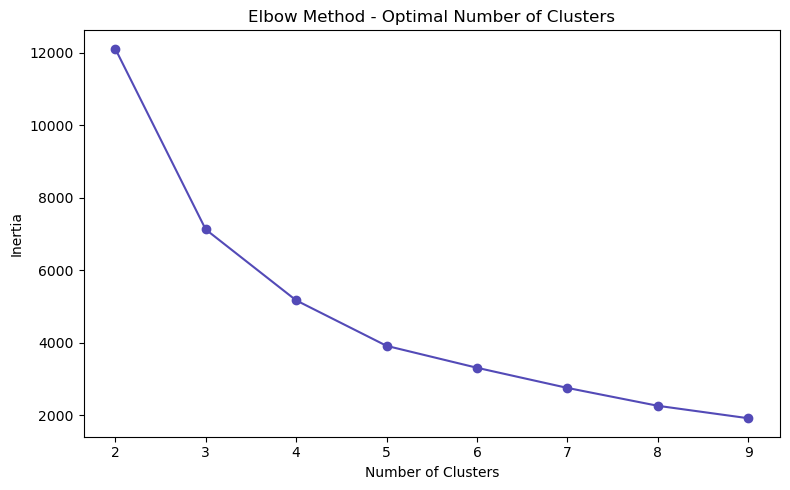

Elbow curve saved.


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# prepare features for clustering
X = rfm[['recency', 'frequency', 'monetary']].copy()

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# find optimal clusters using elbow method
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o', color='#534AB7')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig(r'C:\Users\sahil\ecommerce_project\screenshots\02_elbow_curve.png', dpi=150)
plt.show()

print("Elbow curve saved.")

In [15]:
# train KMeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

# see cluster sizes
print(rfm['cluster'].value_counts())

# see cluster characteristics
print("\nCluster summary:")
print(rfm.groupby('cluster')[['recency','frequency','monetary']].mean().round(2))

cluster
0    3840
1    1999
3      35
2       4
Name: count, dtype: int64

Cluster summary:
         recency  frequency   monetary
cluster                               
0          65.49       7.31    3009.31
1         461.49       2.21     766.55
2           2.00     212.50  436835.79
3          24.54     103.71   83086.08


In [17]:
# label clusters
cluster_labels = {
    0: 'Active Customers',
    1: 'Lost Customers',
    2: 'VIP Champions',
    3: 'Loyal High Value'
}

rfm['segment'] = rfm['cluster'].map(cluster_labels)

print(rfm['segment'].value_counts())
print(f"\nSegment revenue summary:")
print(rfm.groupby('segment')['monetary'].agg(['sum','mean','count']).round(2))

segment
Active Customers    3840
Lost Customers      1999
Loyal High Value      35
VIP Champions          4
Name: count, dtype: int64

Segment revenue summary:
                          sum       mean  count
segment                                        
Active Customers  11555748.94    3009.31   3840
Lost Customers     1532324.26     766.55   1999
Loyal High Value   2908012.79   83086.08     35
VIP Champions      1747343.17  436835.79      4


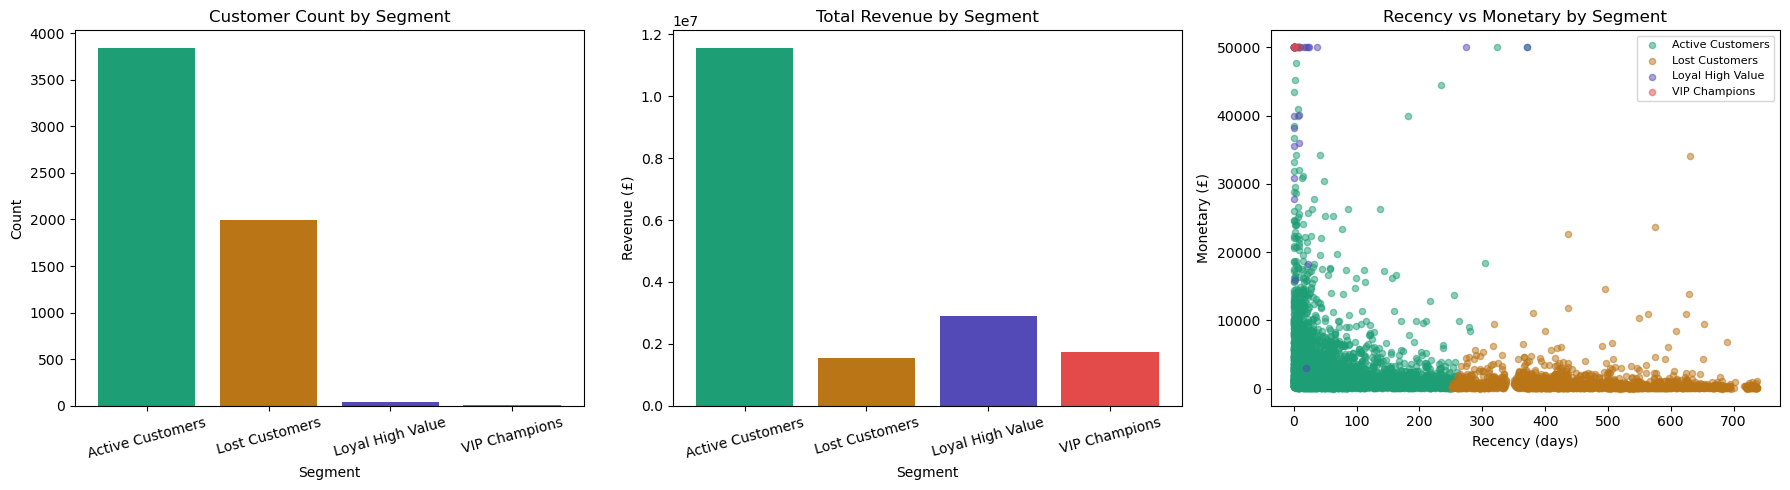

Segment plots saved.


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {
    'VIP Champions'    : '#E24B4A',
    'Loyal High Value' : '#534AB7',
    'Active Customers' : '#1D9E75',
    'Lost Customers'   : '#BA7517'
}

# Plot 1 — Customer count by segment
segment_counts = rfm['segment'].value_counts()
axes[0].bar(segment_counts.index, segment_counts.values,
            color=[colors[s] for s in segment_counts.index])
axes[0].set_title('Customer Count by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Plot 2 — Revenue by segment
segment_revenue = rfm.groupby('segment')['monetary'].sum()
axes[1].bar(segment_revenue.index, segment_revenue.values,
            color=[colors[s] for s in segment_revenue.index])
axes[1].set_title('Total Revenue by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Revenue (£)')
axes[1].tick_params(axis='x', rotation=15)

# Plot 3 — Scatter plot recency vs monetary
for segment in rfm['segment'].unique():
    mask = rfm['segment'] == segment
    axes[2].scatter(
        rfm[mask]['recency'],
        rfm[mask]['monetary'].clip(upper=50000),
        label=segment,
        color=colors[segment],
        alpha=0.5,
        s=20
    )
axes[2].set_title('Recency vs Monetary by Segment')
axes[2].set_xlabel('Recency (days)')
axes[2].set_ylabel('Monetary (£)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(r'C:\Users\sahil\ecommerce_project\screenshots\03_segments.png', dpi=150)
plt.show()

print("Segment plots saved.")

In [21]:
# export RFM segments to SQL Server
rfm_export = rfm[['customer_id', 'recency', 'frequency', 'monetary', 'clv', 'segment']].copy()

rfm_export.to_sql(
    name      = 'rfm_segments',
    con       = engine,
    if_exists = 'replace',
    index     = False
)

print(f"Done. {len(rfm_export)} rows pushed to SQL Server.")

Done. 5878 rows pushed to SQL Server.
